In [4]:
import pandas as pd
import textwrap

PARQUET_FILE = "data_files/flattened_cbo_reports_centroid_similarity.parquet"
df2 = pd.read_parquet(PARQUET_FILE)

TARGETS = {"Social Security", "Medicaid", "Medicare"}

# ---- adjust these only ----
N_SHOW = 10
CENTROID_BAND_MIN = 0.70
CENTROID_BAND_MAX = 0.90
NEARMISS_MIN = 0.34
NEARMISS_MAX = 0.70

TEXT_WIDTH = 110
MAX_LINES = 6

def wrap_text(s, width=TEXT_WIDTH, max_lines=MAX_LINES):
    s = "" if pd.isna(s) else str(s)
    s = " ".join(s.split())
    lines = textwrap.wrap(s, width=width)
    if len(lines) > max_lines:
        lines = lines[:max_lines] + ["...[truncated]"]
    return "\n".join(lines)

def print_rows(title, out, label_col, score_col=None, n=N_SHOW, ascending=False):
    print("\n" + title)
    if out.empty:
        print("(none)")
        return

    if score_col is not None:
        out = out.sort_values(score_col, ascending=ascending)

    out = out.head(n).copy()
    out["text"] = out["text"].apply(wrap_text)

    for _, r in out.iterrows():
        print("-" * 100)
        print(f"{r.get('report_name','?')} | para {r.get('paragraph_number','?')}")
        extra = f"method: {r.get('match_method', pd.NA)} | label: {r[label_col]}"
        if score_col is not None:
            extra += f" | score: {r[score_col]:.3f}"
        print(extra)
        print(r["text"])

# ------------------------------------------------------------
# 0) quick sanity counts (tells you why something prints "none")
# ------------------------------------------------------------
print("\n=== COUNTS FOR TARGETS ===")
print(df2[df2["subcategory"].isin(TARGETS)]["match_method"].value_counts(dropna=False))

# ------------------------------------------------------------
# 1) Literal matches for targets (Tier 1)
# ------------------------------------------------------------
literal = df2[
    (df2["match_method"] == "literal") &
    (df2["subcategory"].isin(TARGETS))
][["report_name","paragraph_number","match_method","subcategory","text"]]

print_rows(
    title=f"Literal matches to {sorted(TARGETS)}",
    out=literal,
    label_col="subcategory",
    score_col=None,
    n=N_SHOW,
)

# ------------------------------------------------------------
# 2) Centroid matches for targets (Tier 2) within a score band
# ------------------------------------------------------------
centroid = df2[
    (df2["match_method"] == "centroid") &
    (df2["subcategory"].isin(TARGETS))
].copy()

centroid["similarity_score"] = pd.to_numeric(centroid["similarity_score"], errors="coerce")

centroid_band = centroid[
    centroid["similarity_score"].between(CENTROID_BAND_MIN, CENTROID_BAND_MAX)
][["report_name","paragraph_number","match_method","subcategory","similarity_score","text"]]

print_rows(
    title=f"Centroid matches to {sorted(TARGETS)} (score {CENTROID_BAND_MIN}–{CENTROID_BAND_MAX})",
    out=centroid_band,
    label_col="subcategory",
    score_col="similarity_score",
    n=N_SHOW,
    ascending=True,   # show weakest in band first
)

# Also show top centroid matches (often these are >0.9, which is why your 0.5–0.7 band looked empty)
centroid_top = centroid[["report_name","paragraph_number","match_method","subcategory","similarity_score","text"]]
print_rows(
    title=f"Top centroid matches to {sorted(TARGETS)} (highest scores)",
    out=centroid_top,
    label_col="subcategory",
    score_col="similarity_score",
    n=N_SHOW,
    ascending=False,
)

# ------------------------------------------------------------
# 3) Near-misses: unclassified rows whose best_subcategory is a target
# ------------------------------------------------------------
un = df2[df2["subcategory"].isna()].copy()
un["best_similarity"] = pd.to_numeric(un["best_similarity"], errors="coerce")

near = un[
    un["best_subcategory"].isin(TARGETS) &
    un["best_similarity"].between(NEARMISS_MIN, NEARMISS_MAX)
][["report_name","paragraph_number","best_subcategory","best_similarity","text"]]

print_rows(
    title=f"Unclassified near-misses where best_subcategory is {sorted(TARGETS)} (score {NEARMISS_MIN}–{NEARMISS_MAX})",
    out=near.rename(columns={"best_subcategory":"label", "best_similarity":"score"}),
    label_col="label",
    score_col="score",
    n=15,
    ascending=False,
)


=== COUNTS FOR TARGETS ===
match_method
literal     3520
centroid    1227
Name: count, dtype: int64

Literal matches to ['Medicaid', 'Medicare', 'Social Security']
----------------------------------------------------------------------------------------------------
2000-01-01__12069__The Budget and Economic Outlook_ Fiscal Years 2001-2010 (Table 1-6 corrected 2_1_00).pdf | para 19
method: literal | label: Social Security
Regardless of the variant, the budgetary picture is a bright one. Between 2001 and 2010, accumulated surpluses
are projected to total $3.2 trillion under the inflated baseline and $4.2 trillion under the freeze or capped
baseline. On-budget surpluses (which exclude the spending and revenues of Social Security and the Postal
Service) total more than $800 billion under the inflated baseline and $1.9 trillion under the other two
baselines.
----------------------------------------------------------------------------------------------------
2000-01-01__12069__The Budget and

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances

PARQUET_FILE = "data_files/flattened_cbo_reports_centroid_similarity.parquet"
CENTROIDS_PARQUET = "data_files/subcategory_centroids.parquet"

# ----------------------------
# Load df + embeddings from main parquet
# ----------------------------
df2 = pd.read_parquet(PARQUET_FILE)

if "embedding" not in df2.columns:
    raise ValueError("Main parquet is missing 'embedding' column.")

E = np.array(df2["embedding"].to_list(), dtype=np.float32)  # (N, 300)

# ----------------------------
# Load centroids from centroid parquet (NEW)
# ----------------------------
cent = pd.read_parquet(CENTROIDS_PARQUET)

if "centroid_embedding" not in cent.columns:
    raise ValueError("Centroids parquet is missing 'centroid_embedding' column.")

centroid_labels = cent["subcategory"].tolist()
C = np.array(cent["centroid_embedding"].to_list(), dtype=np.float32)  # (K, 300)
centroid_by_label = {lab: C[i] for i, lab in enumerate(centroid_labels)}

# ----------------------------
# Define non-total categories
# ----------------------------
EXCLUDE_SUBS = {"Total", "Total Mandatory", "Total Discretionary"}
non_total_labels = [s for s in centroid_labels if s not in EXCLUDE_SUBS]

# ----------------------------
# Summary stats for classified rows (non-total)
# ----------------------------
mask = df2["subcategory"].isin(non_total_labels) & df2["subcategory"].notna()
df_nt = df2.loc[mask, ["subcategory"]].copy()
E_nt = E[mask.to_numpy()]

print("Non-total classified rows:", len(df_nt))

rows = []
PAIRWISE_SAMPLE_N = 250
rng = np.random.RandomState(0)

for sub in df_nt["subcategory"].unique():
    idx = (df_nt["subcategory"] == sub).to_numpy()
    embs = E_nt[idx]

    centroid = centroid_by_label.get(sub)
    if centroid is None or len(embs) == 0:
        continue

    sims = cosine_similarity(embs, centroid.reshape(1, -1)).ravel()
    dists = 1.0 - sims

    # pairwise distance estimate from sample
    if len(embs) > 1:
        k = min(PAIRWISE_SAMPLE_N, len(embs))
        sample = embs[rng.choice(len(embs), size=k, replace=False)]
        pw = pairwise_distances(sample, metric="cosine")
        tri = pw[np.triu_indices_from(pw, k=1)]
        mean_pairwise = float(np.nanmean(tri)) if len(tri) else np.nan
    else:
        mean_pairwise = np.nan

    rows.append({
        "subcategory": sub,
        "n": int(len(embs)),
        "mean_sim_to_centroid": float(np.mean(sims)),
        "mean_dist_to_centroid": float(np.mean(dists)),
        "p10_sim": float(np.quantile(sims, 0.10)),
        "p50_sim": float(np.quantile(sims, 0.50)),
        "p90_sim": float(np.quantile(sims, 0.90)),
        "mean_pairwise_cosine_distance_est": mean_pairwise,
    })

stats = pd.DataFrame(rows).sort_values("n", ascending=False)
display(stats)

print("\nOverall (non-total):")
print({
    "n_total": int(stats["n"].sum()),
    "mean_sim_to_centroid_weighted": float(np.average(stats["mean_sim_to_centroid"], weights=stats["n"])),
    "mean_dist_to_centroid_weighted": float(np.average(stats["mean_dist_to_centroid"], weights=stats["n"])),
})

Non-total classified rows: 10304


,subcategory,n,mean_sim_to_centroid,mean_dist_to_centroid,p10_sim,p50_sim,p90_sim,mean_pairwise_cosine_distance_est
1,Net Interest,3031,0.832401,0.167599,0.737605,0.842431,0.912100,0.287155
2,Social Security,1994,0.830503,0.169497,0.703346,0.859665,0.912122,0.306548
3,Medicare,1510,0.823133,0.176867,0.718443,0.836728,0.904096,0.309441
5,Medicaid,1243,0.839326,0.160674,0.735888,0.850342,0.918869,0.283448
0,Nondefense Discretionary,1094,0.832522,0.167478,0.732727,0.840692,0.916207,0.267356
4,Other Mandatory,863,0.850346,0.149654,0.753449,0.858201,0.922277,0.261006
6,Defense Discretionary,569,0.826977,0.173023,0.738172,0.826570,0.908076,0.265138



Overall (non-total):
{'n_total': 10304, 'mean_sim_to_centroid_weighted': 0.8327271015389088, 'mean_dist_to_centroid_weighted': 0.1672728967054614}


Selected labels: ['Medicare', 'Medicaid', 'Social Security']


,label,cos_sim_to_focus
0,Medicaid,0.980923
1,Social Security,0.975271
2,Other Mandatory,0.971234
3,Net Interest,0.926841
4,Nondefense Discretionary,0.913764
5,Defense Discretionary,0.913165


Explained variance (PC1, PC2): [0.13795032 0.09011383]


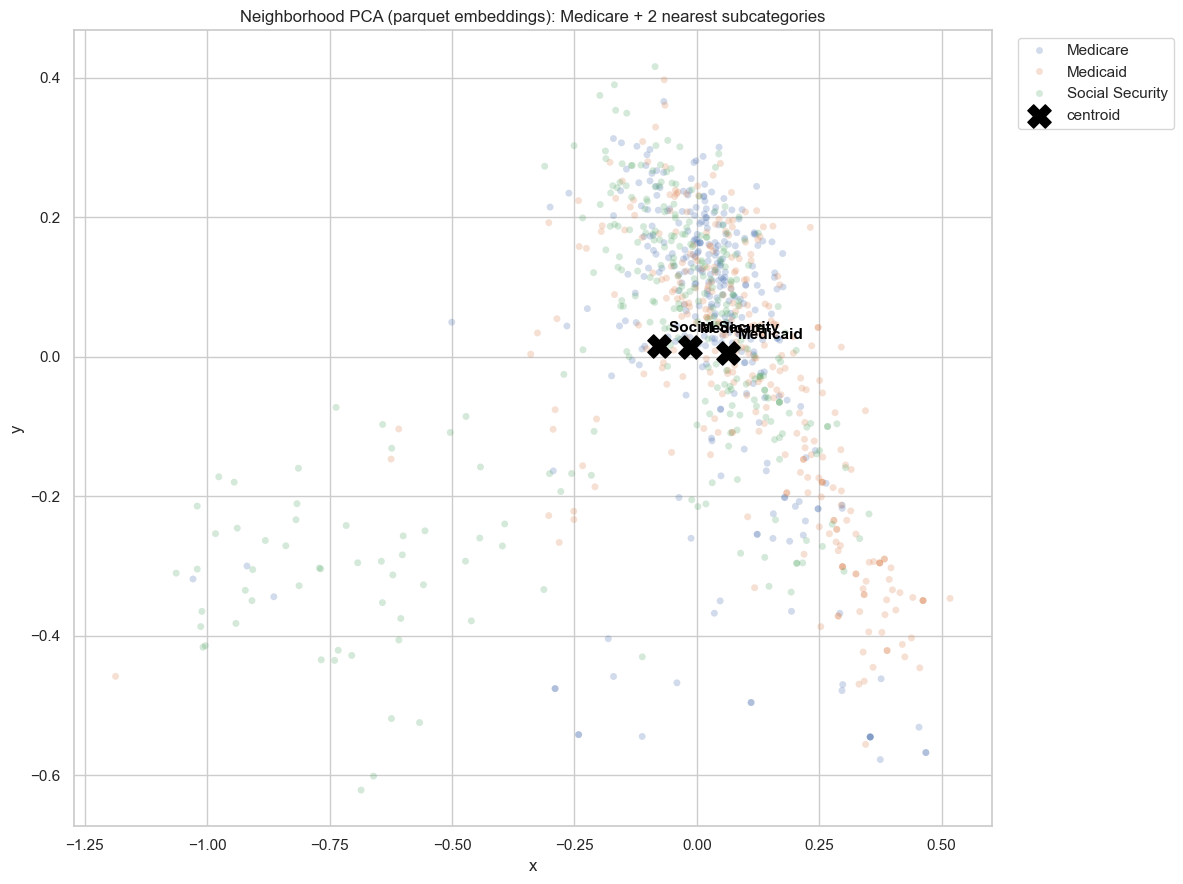

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import re

sns.set(style="whitegrid")

# -----------------------
# Files (NEW structure)
# -----------------------
PARQUET_FILE = "data_files/flattened_cbo_reports_centroid_similarity.parquet"
CENTROIDS_PARQUET = "data_files/subcategory_centroids.parquet"

# -----------------------
# Parameters
# -----------------------
FOCUS_LABEL = "Medicare"
K_NEIGHBORS = 2
SAMPLE_PER_LABEL = 300

EXCLUDE_SUBS = {"Total", "Total Mandatory", "Total Discretionary"}

# Turn this on only if you want stars (loads Word2Vec)
SHOW_NEIGHBOR_WORDS = False
NEIGHBORS_PER_LABEL = 8
ANNOTATE_PER_LABEL = 2

# -----------------------
# Load main df + embeddings from parquet
# -----------------------
df2 = pd.read_parquet(PARQUET_FILE)

if "embedding" not in df2.columns:
    raise ValueError("Main parquet missing 'embedding' column.")

E = np.array(df2["embedding"].to_list(), dtype=np.float32)  # (N, 300)

# -----------------------
# Load centroids from centroids parquet
# -----------------------
cent = pd.read_parquet(CENTROIDS_PARQUET)

if "centroid_embedding" not in cent.columns:
    raise ValueError("Centroids parquet missing 'centroid_embedding' column.")

centroid_labels = cent["subcategory"].tolist()
centroid_matrix = np.array(cent["centroid_embedding"].to_list(), dtype=np.float32)
centroid_by_label = {lab: centroid_matrix[i] for i, lab in enumerate(centroid_labels)}

plot_labels = [s for s in centroid_labels if s not in EXCLUDE_SUBS]

# sanity check: embedding dims match
if E.shape[1] != centroid_matrix.shape[1]:
    raise ValueError(f"Dim mismatch: paragraph embeddings {E.shape[1]} vs centroids {centroid_matrix.shape[1]}")

# -----------------------
# Choose nearest subcategories in ORIGINAL 300d space
# -----------------------
def nearest_labels_by_centroid_cosine(focus, labels, centroid_map, k=2):
    if focus not in centroid_map:
        raise ValueError(f"Focus label '{focus}' not in centroids.")
    focus_vec = centroid_map[focus].reshape(1, -1)

    others = [l for l in labels if l != focus and l in centroid_map]
    other_mat = np.vstack([centroid_map[l] for l in others]).astype(np.float32)

    sims = cosine_similarity(focus_vec, other_mat).ravel()
    order = np.argsort(-sims)[:k]
    nearest = [others[i] for i in order]

    table = (
        pd.DataFrame({"label": others, "cos_sim_to_focus": sims})
        .sort_values("cos_sim_to_focus", ascending=False)
        .reset_index(drop=True)
    )
    return [focus] + nearest, table

selected_labels, sim_table = nearest_labels_by_centroid_cosine(
    FOCUS_LABEL, plot_labels, centroid_by_label, k=K_NEIGHBORS
)

print("Selected labels:", selected_labels)
display(sim_table.head(10))

# -----------------------
# Collect points: paragraph embeddings + centroid points
# -----------------------
points = []
rng = np.random.RandomState(1)

# paragraph clouds (from embeddings stored in parquet)
for sub in selected_labels:
    idx = (df2["subcategory"] == sub).to_numpy()
    sub_embs = E[idx]
    if len(sub_embs) == 0:
        continue

    n = min(SAMPLE_PER_LABEL, len(sub_embs))
    samp_idx = rng.choice(len(sub_embs), size=n, replace=False)

    for emb in sub_embs[samp_idx]:
        if np.linalg.norm(emb) == 0:
            continue
        points.append({"type": "paragraph", "label": sub, "name": None, "emb": emb})

# centroid points
for sub in selected_labels:
    points.append({"type": "centroid", "label": sub, "name": sub, "emb": centroid_by_label[sub]})

# optional: neighbor words (stars)
if SHOW_NEIGHBOR_WORDS:
    import gensim.downloader as api
    import nltk
    from nltk.corpus import stopwords

    try:
        stop_words = set(stopwords.words("english"))
    except LookupError:
        nltk.download("stopwords", quiet=True)
        stop_words = set(stopwords.words("english"))

    w2v_model = api.load("word2vec-google-news-300")

    def keep_neighbor_word(w: str) -> bool:
        if w.lower() in stop_words:
            return False
        if re.fullmatch(r"\d+", w):
            return False
        if len(w) <= 2:
            return False
        if re.fullmatch(r"[A-Z]{3,}", w):  # acronyms
            return False
        if "_" in w or "/" in w:
            return False
        if re.search(r"\d", w):
            return False
        return True

    for sub in selected_labels:
        vec = centroid_by_label[sub]
        nbrs = w2v_model.similar_by_vector(vec, topn=NEIGHBORS_PER_LABEL * 10)

        kept = []
        for w, sc in nbrs:
            if len(kept) >= NEIGHBORS_PER_LABEL:
                break
            if not keep_neighbor_word(w):
                continue
            kept.append((w, sc))

        for w, sc in kept:
            points.append({
                "type": "neighbor_word",
                "label": sub,
                "name": w,
                "score": float(sc),
                "emb": w2v_model[w].astype(np.float32),
            })

# -----------------------
# PCA on just these points
# -----------------------
X = np.vstack([p["emb"] for p in points]).astype(np.float32)
pca = PCA(n_components=2, random_state=1)
X2 = pca.fit_transform(X)

for i, p in enumerate(points):
    p["x"] = X2[i, 0]
    p["y"] = X2[i, 1]

df_small = pd.DataFrame([{k: v for k, v in p.items() if k != "emb"} for p in points])
print("Explained variance (PC1, PC2):", pca.explained_variance_ratio_)

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(12, 9))

sns.scatterplot(
    data=df_small[df_small["type"] == "paragraph"],
    x="x", y="y",
    hue="label",
    alpha=0.25,
    s=25,
    linewidth=0,
)

cent_df = df_small[df_small["type"] == "centroid"]
plt.scatter(cent_df["x"], cent_df["y"], c="black", s=280, marker="X", label="centroid")

# label centroids directly so you can tell which is which
for _, r in cent_df.iterrows():
    plt.text(r["x"] + 0.02, r["y"] + 0.02, r["label"], fontsize=11, weight="bold", color="black")

if SHOW_NEIGHBOR_WORDS:
    nbr = df_small[df_small["type"] == "neighbor_word"]
    plt.scatter(nbr["x"], nbr["y"], c="gray", s=90, marker="*", alpha=0.85, label="neighbor word")

    for lab in selected_labels:
        sub_nbr = nbr[nbr["label"] == lab].sort_values("score", ascending=False).head(ANNOTATE_PER_LABEL)
        for _, r in sub_nbr.iterrows():
            plt.text(r["x"] + 0.02, r["y"] + 0.02, f"{lab}:{r['name']}", fontsize=9, color="dimgray")

plt.title(f"Neighborhood PCA (parquet embeddings): {FOCUS_LABEL} + {K_NEIGHBORS} nearest subcategories")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()